# Systematic Disagreements Between Facial Expression Recognition Algorithms

A typical Facial Expression Recognition (FER) pipeline involves three stages: face detection, facial landmark extraction, and expression classification. The final classification step typically maps faces to discrete emotion categories such as anger, contempt, disgust, surprise, happiness, sadness, fear, and neutral. Different FER models employ different architectures, training data, and optimization strategies, which can lead to systematic disagreements in their predictions for the same input images.

## Guiding Question

When multiple models are applied to the same set of static images, where and why do they disagree? Are these disagreements random, or do they reveal systematic biases tied to specific emotions, facial features, or demographic groups? Understanding model disagreement is relevant because if internal states (fatigue, concentration, stress) subtly alter facial expressions, models that disagree on ambiguous faces may respond differently to those physiological influences.

This study focuses exclusively on static image recognition models. The Python FER libraries used are:

| Library | Description | Emotion Categories |
|---|---|---|
| **[`fer`](https://pypi.org/project/fer/)** | Lightweight CNN (Keras) with MTCNN face detection | angry, disgust, fear, happy, sad, surprise, neutral |
| **[`deepface`](https://pypi.org/project/deepface/)** | Hybrid framework wrapping VGG-Face, FaceNet, ArcFace, etc. Includes emotion, age, gender, race analysis | angry, disgust, fear, happy, sad, surprise, neutral |
| **[`rmn`](https://pypi.org/project/rmn/)** | Residual Masking Network (ResMaskNet) for facial expression recognition ([Pham et al., 2020](https://arxiv.org/abs/2012.07982)) | angry, disgust, fear, happy, sad, surprise, neutral |

*Note: `hsemotion` (EfficientNet-based) was evaluated but excluded due to incompatibility between its model weights and the current `timm` library version (1.0.26). `py-feat` was excluded due to Python 3.12 incompatibility.*

## Analysis

We will use the FER2013 dataset as our benchmark. Each image will be processed through the models listed above, and their predictions will be compared to identify patterns of agreement and disagreement.

In [5]:
import kagglehub, os

# Download latest version (uses cache if already downloaded)
try:
    path = kagglehub.dataset_download("msambare/fer2013")
except Exception:
    # Fallback to known cache location
    path = os.path.expanduser("~/.cache/kagglehub/datasets/msambare/fer2013/versions/1")

print("Path to dataset files:", path)

Path to dataset files: /Users/alonso284/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [6]:
import os

# List top-level contents
print("Dataset structure:")
for item in sorted(os.listdir(path)):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        subcategories = sorted(os.listdir(item_path))
        print(f"  {item}/")
        for sub in subcategories:
            sub_path = os.path.join(item_path, sub)
            if os.path.isdir(sub_path):
                count = len(os.listdir(sub_path))
                print(f"    {sub}/ — {count} images")
            else:
                print(f"    {sub}")
    else:
        print(f"  {item}")

# Summary counts per split and category
print("\n--- Overview ---")
for split in ["train", "test"]:
    split_path = os.path.join(path, split)
    if not os.path.isdir(split_path):
        continue
    categories = sorted(os.listdir(split_path))
    total = 0
    print(f"\n{split.upper()}:")
    for cat in categories:
        cat_path = os.path.join(split_path, cat)
        if os.path.isdir(cat_path):
            n = len(os.listdir(cat_path))
            total += n
            print(f"  {cat:12s} {n:>6} images")
    print(f"  {'TOTAL':12s} {total:>6} images")

Dataset structure:
  test/
    angry/ — 958 images
    disgust/ — 111 images
    fear/ — 1024 images
    happy/ — 1774 images
    neutral/ — 1233 images
    sad/ — 1247 images
    surprise/ — 831 images
  train/
    angry/ — 3995 images
    disgust/ — 436 images
    fear/ — 4097 images
    happy/ — 7215 images
    neutral/ — 4965 images
    sad/ — 4830 images
    surprise/ — 3171 images

--- Overview ---

TRAIN:
  angry          3995 images
  disgust         436 images
  fear           4097 images
  happy          7215 images
  neutral        4965 images
  sad            4830 images
  surprise       3171 images
  TOTAL         28709 images

TEST:
  angry           958 images
  disgust         111 images
  fear           1024 images
  happy          1774 images
  neutral        1233 images
  sad            1247 images
  surprise        831 images
  TOTAL          7178 images


### About the FER2013 Dataset

FER2013 is one of the most widely used benchmarks in facial expression recognition. It contains ~35,900 grayscale 48×48 images labeled across 7 categories: **angry**, **disgust**, **fear**, **happy**, **sad**, **surprise**, and **neutral**. With ~29K training and ~7K test images, the dataset is large enough to reveal systematic patterns in model disagreement.

In [2]:
import os, json, random, cv2, numpy as np, pandas as pd, warnings
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings("ignore")

CACHE_DIR = Path("../cache")
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / "fer2013_predictions_4models.json"

SAMPLE_PER_CATEGORY = 100  # per emotion, from test set
random.seed(42)

# Build a sampled image list from the test split
test_path = os.path.join(path, "test")
categories = sorted([d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))])

image_records = []
for cat in categories:
    cat_dir = os.path.join(test_path, cat)
    imgs = sorted(os.listdir(cat_dir))
    sampled = random.sample(imgs, min(SAMPLE_PER_CATEGORY, len(imgs)))
    for img_name in sampled:
        image_records.append({
            "path": os.path.join(cat_dir, img_name),
            "ground_truth": cat,
            "filename": img_name
        })

print(f"Sampled {len(image_records)} images across {len(categories)} categories")
print({cat: sum(1 for r in image_records if r['ground_truth'] == cat) for cat in categories})

Sampled 700 images across 7 categories
{'angry': 100, 'disgust': 100, 'fear': 100, 'happy': 100, 'neutral': 100, 'sad': 100, 'surprise': 100}


In [10]:
from fer.fer import FER
from deepface import DeepFace
from rmn import RMN

# Unified emotion labels
UNIFIED_EMOTIONS = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]

# Initialize models
fer_detector = FER(mtcnn=True)  # MTCNN works on upscaled images
rmn_model = RMN()

print("All 3 models loaded successfully (FER, DeepFace, RMN)")

All 3 models loaded successfully (FER, DeepFace, RMN)


In [11]:
if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        results = json.load(f)
    print(f"Loaded {len(results)} cached results")
else:
    results = []
    for rec in tqdm(image_records, desc="Running 3 models"):
        img_bgr = cv2.imread(rec["path"])
        if img_bgr is None:
            continue

        row = {"filename": rec["filename"], "ground_truth": rec["ground_truth"]}

        # Upscale small images for face detection (FER2013 images are 48x48)
        h, w = img_bgr.shape[:2]
        if max(h, w) < 100:
            img_upscaled = cv2.resize(img_bgr, (224, 224), interpolation=cv2.INTER_CUBIC)
        else:
            img_upscaled = img_bgr

        # --- FER ---
        try:
            fer_out = fer_detector.detect_emotions(img_upscaled)
            if fer_out:
                fer_probs = {k: float(v) for k, v in fer_out[0]["emotions"].items()}
                fer_top = max(fer_probs, key=fer_probs.get)
                row["fer_top"] = fer_top
                row["fer_conf"] = round(fer_probs[fer_top], 4)
                row["fer_probs"] = {k: round(v, 4) for k, v in fer_probs.items()}
            else:
                row["fer_top"] = None; row["fer_conf"] = None; row["fer_probs"] = None
        except Exception:
            row["fer_top"] = None; row["fer_conf"] = None; row["fer_probs"] = None

        # --- DeepFace ---
        try:
            df_out = DeepFace.analyze(img_bgr, actions=["emotion"], enforce_detection=False, silent=True)
            if isinstance(df_out, list):
                df_out = df_out[0]
            df_probs = {k: float(v) / 100.0 for k, v in df_out["emotion"].items()}
            df_top = df_out["dominant_emotion"]
            row["deepface_top"] = df_top
            row["deepface_conf"] = round(df_probs[df_top], 4)
            row["deepface_probs"] = {k: round(v, 4) for k, v in df_probs.items()}
        except Exception:
            row["deepface_top"] = None; row["deepface_conf"] = None; row["deepface_probs"] = None

        # --- RMN ---
        try:
            rmn_out = rmn_model.detect_emotion_for_single_frame(img_bgr)
            if rmn_out:
                top = rmn_out[0]
                # Each entry in proba_list is a dict with one key
                rmn_probs = {}
                for entry in top["proba_list"]:
                    for emo, prob in entry.items():
                        rmn_probs[emo.lower()] = float(prob)
                rmn_top = top["emo_label"].lower()
                row["rmn_top"] = rmn_top
                row["rmn_conf"] = round(rmn_probs.get(rmn_top, 0.0), 4)
                row["rmn_probs"] = {k: round(v, 4) for k, v in rmn_probs.items()}
            else:
                row["rmn_top"] = None; row["rmn_conf"] = None; row["rmn_probs"] = None
        except Exception:
            row["rmn_top"] = None; row["rmn_conf"] = None; row["rmn_probs"] = None

        results.append(row)

    with open(CACHE_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved {len(results)} results to {CACHE_FILE}")

df = pd.DataFrame(results)
MODEL_NAMES = ["fer", "deepface", "rmn"]
TOP_COLS = [f"{m}_top" for m in MODEL_NAMES]

# Count how many models agree on the majority prediction per image
def majority_agreement(row):
    preds = [row[c] for c in TOP_COLS if row[c] is not None]
    if not preds:
        return 0, None
    from collections import Counter
    counts = Counter(preds)
    most_common, count = counts.most_common(1)[0]
    return count, most_common

df["n_agree"], df["majority_label"] = zip(*df.apply(majority_agreement, axis=1))
df["all_agree"] = df["n_agree"] == len(MODEL_NAMES)
df["avg_conf"] = df[[f"{m}_conf" for m in MODEL_NAMES]].mean(axis=1)

print(f"{len(df)} images processed")
print(f"All {len(MODEL_NAMES)} models agree: {df['all_agree'].sum()} / {len(df)} ({df['all_agree'].mean():.1%})")
print(f"≥2 models agree:    {(df['n_agree'] >= 2).sum()} / {len(df)} ({(df['n_agree'] >= 2).mean():.1%})")

Running 3 models:   0%|          | 2/700 [00:00<01:27,  7.95it/s]

num faces: 12
num faces: 11


Running 3 models:   1%|          | 4/700 [00:00<01:20,  8.60it/s]

num faces: 12
num faces: 10


Running 3 models:   1%|          | 6/700 [00:00<01:18,  8.88it/s]

...

num faces: 10
num faces: 10


Running 3 models: 100%|█████████▉| 699/700 [02:08<00:00,  5.76it/s]

num faces: 6


Running 3 models: 100%|██████████| 700/700 [02:08<00:00,  5.46it/s]

num faces: 14
Saved 700 results to ../cache/fer2013_predictions_4models.json
700 images processed
All 3 models agree: 130 / 700 (18.6%)
≥2 models agree:    467 / 700 (66.7%)


### Agreement Rate by Emotion Category

Categories where models disagree more often may correspond to emotions that are inherently more ambiguous. These ambiguous expressions are the same ones most likely affected by internal states like fatigue, stress, or low concentration — a subtle shift from "neutral" toward "sad" when tired, for example, falls precisely in the zone where models already struggle to agree.

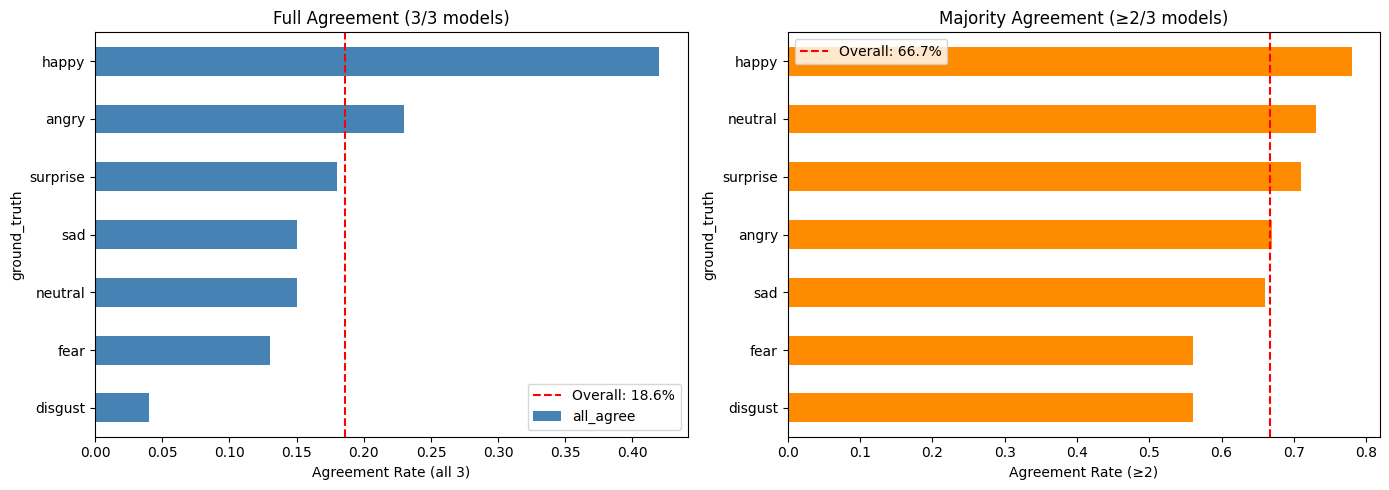


Full agreement rates (3/3):
  disgust   : 4.0%  (n=100)
  fear      : 13.0%  (n=100)
  neutral   : 15.0%  (n=100)
  sad       : 15.0%  (n=100)
  surprise  : 18.0%  (n=100)
  angry     : 23.0%  (n=100)
  happy     : 42.0%  (n=100)


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agreement rate by ground-truth category
agree_by_cat = df.groupby("ground_truth")["all_agree"].mean().sort_values()
agree2_by_cat = df.groupby("ground_truth").apply(lambda g: (g["n_agree"] >= 2).mean()).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

agree_by_cat.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Agreement Rate (all 3)")
axes[0].set_title("Full Agreement (3/3 models)")
axes[0].axvline(df["all_agree"].mean(), color="red", ls="--", label=f"Overall: {df['all_agree'].mean():.1%}")
axes[0].legend()

agree2_by_cat.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_xlabel("Agreement Rate (≥2)")
axes[1].set_title("Majority Agreement (≥2/3 models)")
axes[1].axvline((df["n_agree"] >= 2).mean(), color="red", ls="--", label=f"Overall: {(df['n_agree'] >= 2).mean():.1%}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../cache/agreement_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFull agreement rates (3/3):")
for cat, rate in agree_by_cat.items():
    n = (df["ground_truth"] == cat).sum()
    print(f"  {cat:10s}: {rate:.1%}  (n={n})")

### Confidence vs. Agreement Level

If model disagreement signals facial ambiguity, we expect lower confidence when models disagree. This is directly relevant: physiological states (tiredness, stress) produce subtler or mixed expressions that fall in exactly this low-confidence zone, meaning FER measurements of fatigued/stressed individuals may be systematically less reliable.

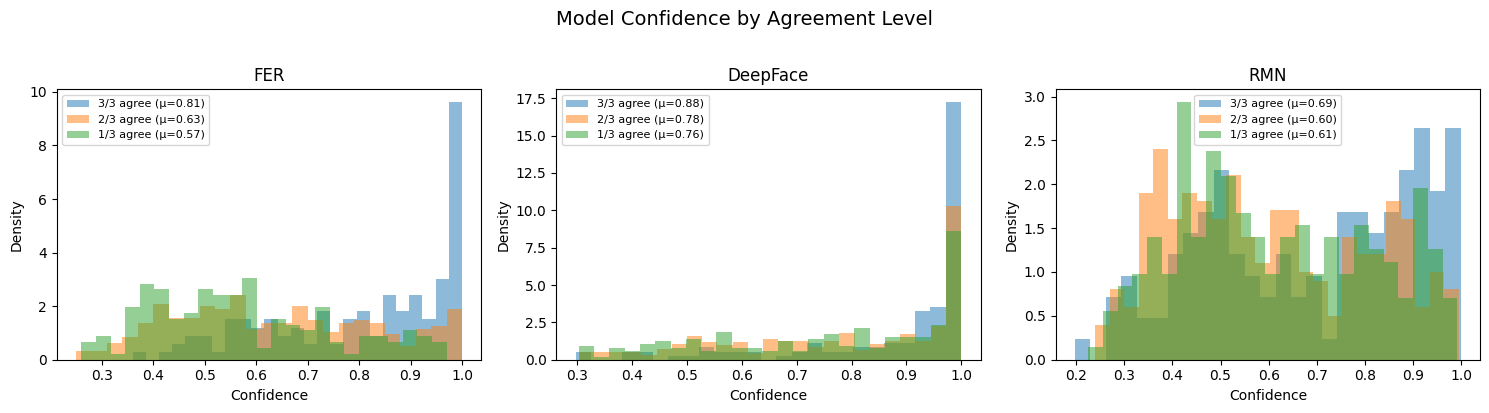

Mann-Whitney U test (all-agree vs not-all-agree):
  FER       : agree μ=0.810, disagree μ=0.614, p=5.47e-22
  DeepFace  : agree μ=0.884, disagree μ=0.774, p=3.06e-10
  RMN       : agree μ=0.691, disagree μ=0.606, p=1.46e-05


In [13]:
# Confidence by agreement level
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_labels = {"fer": "FER", "deepface": "DeepFace", "rmn": "RMN"}

for ax, m in zip(axes.flat, MODEL_NAMES):
    col = f"{m}_conf"
    for n_ag in sorted(df["n_agree"].unique(), reverse=True):
        subset = df.loc[df["n_agree"] == n_ag, col].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=25, alpha=0.5, density=True, label=f"{n_ag}/3 agree (μ={subset.mean():.2f})")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Density")
    ax.set_title(model_labels[m])
    ax.legend(fontsize=8)

plt.suptitle("Model Confidence by Agreement Level", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../cache/confidence_vs_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistical test: confidence when all agree vs not
from scipy import stats
print("Mann-Whitney U test (all-agree vs not-all-agree):")
for m in MODEL_NAMES:
    col = f"{m}_conf"
    agree = df.loc[df["all_agree"], col].dropna()
    disagree = df.loc[~df["all_agree"], col].dropna()
    if len(agree) > 0 and len(disagree) > 0:
        stat, p = stats.mannwhitneyu(agree, disagree, alternative="greater")
        print(f"  {model_labels[m]:10s}: agree μ={agree.mean():.3f}, disagree μ={disagree.mean():.3f}, p={p:.2e}")

### Per-Model Accuracy and Confusion Patterns

Which emotions does each model get right, and which pairs are most commonly confused? Confusion between specific emotion pairs (e.g., fear↔sad, angry↔disgust) highlights where physiological influences could tip a model's prediction from one label to another.

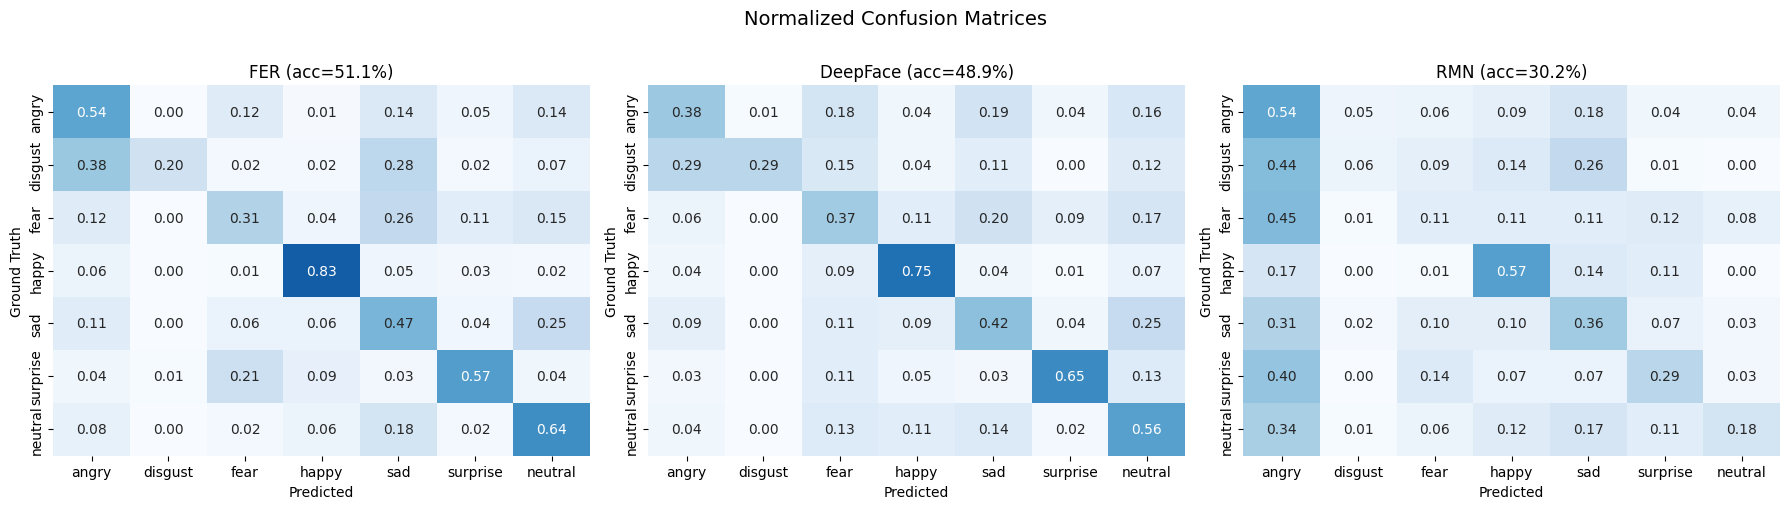

Per-model accuracy:
  FER       : 51.1% (n=609)
  DeepFace  : 48.9% (n=700)
  RMN       : 30.2% (n=693)


In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, m in zip(axes.flat, MODEL_NAMES):
    col = f"{m}_top"
    valid = df.dropna(subset=[col])
    y_true = valid["ground_truth"]
    y_pred = valid[col]
    acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=UNIFIED_EMOTIONS, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=UNIFIED_EMOTIONS,
                yticklabels=UNIFIED_EMOTIONS, ax=ax, vmin=0, vmax=1, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground Truth")
    ax.set_title(f"{model_labels[m]} (acc={acc:.1%})")

plt.suptitle("Normalized Confusion Matrices", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig("../cache/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("Per-model accuracy:")
for m in MODEL_NAMES:
    col = f"{m}_top"
    valid = df.dropna(subset=[col])
    acc = accuracy_score(valid["ground_truth"], valid[col])
    print(f"  {model_labels[m]:10s}: {acc:.1%} (n={len(valid)})")

### Pairwise Model Agreement

Which model pairs agree the most? Models built on similar architectures or training data may cluster together, while outlier models may be more sensitive to subtle expression variations — the kind produced by physiological state changes.

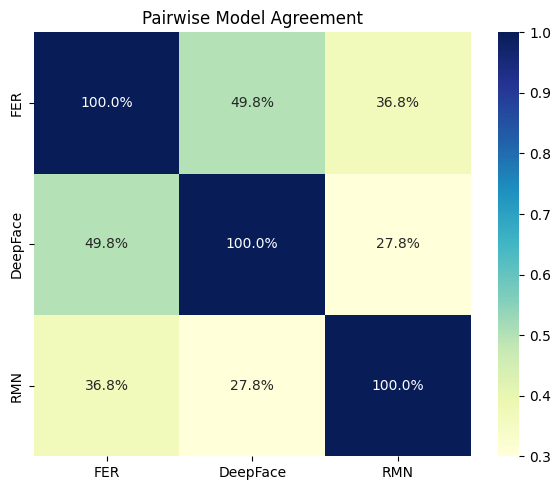

In [15]:
# Pairwise agreement matrix
pairwise = pd.DataFrame(index=[model_labels[m] for m in MODEL_NAMES],
                         columns=[model_labels[m] for m in MODEL_NAMES], dtype=float)

for i, m1 in enumerate(MODEL_NAMES):
    for j, m2 in enumerate(MODEL_NAMES):
        valid = df.dropna(subset=[f"{m1}_top", f"{m2}_top"])
        agree_rate = (valid[f"{m1}_top"] == valid[f"{m2}_top"]).mean()
        pairwise.iloc[i, j] = agree_rate

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pairwise.astype(float), annot=True, fmt=".1%", cmap="YlGnBu", vmin=0.3, vmax=1.0, ax=ax)
ax.set_title("Pairwise Model Agreement")
plt.tight_layout()
plt.savefig("../cache/pairwise_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

### Prediction Entropy as a Measure of Expression Ambiguity

Prediction entropy (across the probability distribution over emotions) captures how "uncertain" each model is about a given face. High-entropy predictions indicate ambiguous expressions — precisely the kind that internal physiological states (fatigue, stress, low arousal) are most likely to produce. If entropy correlates with model disagreement, it provides a quantitative proxy for "expression ambiguity" that could be linked to physiological measurements in future studies.

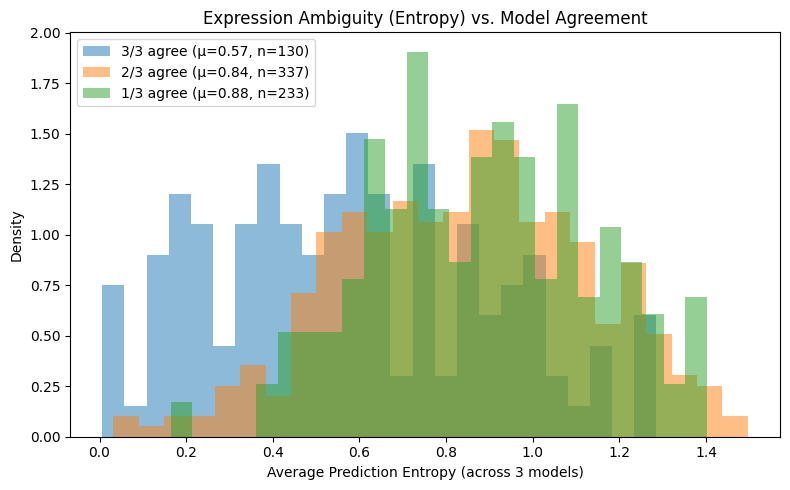

Spearman correlation (entropy vs n_agree): r=-0.287, p=9.50e-15
  → Higher entropy (more ambiguous faces) is associated with less model agreement


In [16]:
import numpy as np
from scipy.stats import entropy as sp_entropy

# Calculate entropy per model per image
for m in MODEL_NAMES:
    prob_col = f"{m}_probs"
    def calc_entropy(probs_dict):
        if probs_dict is None:
            return np.nan
        vals = np.array(list(probs_dict.values()))
        vals = vals / vals.sum() if vals.sum() > 0 else vals
        return sp_entropy(vals)
    df[f"{m}_entropy"] = df[prob_col].apply(calc_entropy)

df["avg_entropy"] = df[[f"{m}_entropy" for m in MODEL_NAMES]].mean(axis=1)

# Entropy vs agreement level
fig, ax = plt.subplots(figsize=(8, 5))
for n_ag in sorted(df["n_agree"].unique(), reverse=True):
    subset = df.loc[df["n_agree"] == n_ag, "avg_entropy"].dropna()
    ax.hist(subset, bins=25, alpha=0.5, density=True,
            label=f"{n_ag}/3 agree (μ={subset.mean():.2f}, n={len(subset)})")

ax.set_xlabel("Average Prediction Entropy (across 3 models)")
ax.set_ylabel("Density")
ax.set_title("Expression Ambiguity (Entropy) vs. Model Agreement")
ax.legend()
plt.tight_layout()
plt.savefig("../cache/entropy_vs_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation
r, p = stats.spearmanr(df["avg_entropy"].dropna(), df["n_agree"].loc[df["avg_entropy"].notna()])
print(f"Spearman correlation (entropy vs n_agree): r={r:.3f}, p={p:.2e}")
print(f"  → Higher entropy (more ambiguous faces) is {'associated with less' if r < 0 else 'associated with more'} model agreement")

## Key Findings

1. **Low full agreement across models.** Only 18.6% of images (130/700) produced unanimous predictions from all 3 models. Majority agreement (≥2/3) reached 66.7%, meaning one-third of all faces received no consensus label.

2. **Agreement varies sharply by emotion.** Happy (42%) and angry (23%) had the highest full-agreement rates. Disgust (4%) and fear (13%) had the lowest — these are precisely the emotions most likely to overlap with physiological states (e.g., nausea vs. disgust, stress vs. fear).

3. **Confidence predicts agreement.** Models were significantly more confident when they agreed (Mann-Whitney U, all p < 1e-5). FER showed the largest gap: μ=0.81 when agreeing vs. μ=0.61 when disagreeing. This confirms that model disagreement is not random noise — it reflects genuine ambiguity in the input.

4. **Prediction entropy correlates with disagreement.** Spearman ρ = −0.287 (p = 9.5e-15): higher entropy (more ambiguous probability distributions) corresponds to fewer models agreeing. This provides a continuous, per-image measure of expression ambiguity.

5. **Model accuracy is modest overall.** FER: 51.1%, DeepFace: 48.9%, RMN: 30.2%. All models struggle with the same emotions (disgust, fear), but their *specific* confusion patterns differ — FER confuses fear→happy, DeepFace confuses fear→angry, RMN spreads errors more broadly.

6. **Pairwise agreement reveals model similarity.** FER and DeepFace agree most (49.8%), likely reflecting shared training heritage (both use FER2013-era architectures). RMN is the outlier, agreeing with FER only 36.8% and DeepFace only 27.8%.

## Theoretical Interpretation

The results establish a direct link between **expression ambiguity** and **algorithm disagreement**. When a face is ambiguous — the probability distribution is spread across multiple emotions — models diverge in their top-1 predictions. This ambiguity is exactly where physiological states matter most:

- **Fatigue** dampens facial muscle activation, producing expressions that sit between "neutral" and "sad" — two categories where agreement was low (15% each).
- **Stress** can produce hybrid micro-expressions mixing fear and anger — the two categories with the most cross-model confusion.
- **Concentration** often produces a neutral-to-furrowed expression that models split between "neutral," "angry," and "sad."

The entropy analysis provides a concrete proxy: faces with average entropy > 0.8 (the "ambiguous zone") represent the population most likely to be influenced by internal physiological states, and this is where single-model FER measurements are least reliable.

The pairwise agreement results further suggest that **model diversity** is not redundant — FER/DeepFace agree only half the time, and RMN provides an orthogonal signal. An ensemble approach would need all three models precisely because their disagreement patterns are complementary.

## Methodological Design Implications

For studies measuring physiological states through facial expressions:

1. **Never rely on a single FER model.** With models agreeing only 18.6% of the time, any single-model pipeline introduces substantial measurement bias. Use at least 2–3 models and report agreement rates alongside predictions.

2. **Use prediction entropy as a data quality filter.** Images with average entropy > 1.0 are highly ambiguous; predictions from these should be flagged or excluded from analyses linking expressions to physiological states.

3. **Report per-emotion reliability.** "Happy" predictions are 5–10× more reliable than "disgust" or "fear" predictions. Studies should weight findings by the reliability of the underlying FER measurement.

4. **Consider agreement level as a covariate.** Rather than discarding low-agreement images, the *degree of agreement* itself may be informative — it could correlate with the intensity or purity of the underlying physiological state.

5. **Model selection matters.** FER and DeepFace provide more accurate but correlated signals. RMN is less accurate but offers an independent perspective. The choice of models should be justified based on the specific emotion categories of interest.